# CNN Classifier with Data Augmentation — Pneumonia vs Healthy

Train `SimpleCNN` on NIH Chest X-ray dataset **with** data augmentation on the training set:  
`RandomRotation` · `RandomHorizontalFlip` · `ColorJitter (brightness)` · `RandomResizedCrop`

Uses `pos_weight` on `BCEWithLogitsLoss` to deal with unbalanced classes.  
Val/Test sets are **not** augmented (standard evaluation).

**Reported metrics:** Accuracy and AUC-ROC on test dataset.

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from classifier import SimpleCNN
from dataset import AugmentedDataset
from device import DEVICE
from metrics import print_metrics, plot_roc_curve
from train_models import run_epoch, train_model, training_curves, save_results
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(f"Device: {DEVICE}")

Device: cuda


## 2. Hyperparameters

In [2]:
from config import load_config

cfg = load_config(project_root / "configs" / "augmented_cnn.yaml", project_root)

print(cfg.model.name)              
print(cfg.model.dropout)            
print(cfg.data.img_size)             
print(cfg.data.augmentation)        
print(cfg.data.class_balancing)     
print(cfg.training.batch_size)       
print(cfg.training.lr)                
print(cfg.training.num_epochs)        
print(cfg.training.weight_decay)     
print(cfg.training.early_stopping_patience) 
print(cfg.seed)               

if cfg.data.augmentations:
    print("Using data augmentation with the following parameters:")
    print(cfg.data.augmentations)
else:
    print("No data augmentation will be applied.")

print(cfg.checkpoint_path)            # .../models/augmented_cnn.pt (derivado)
print(cfg.results_dir)                # .../results/augmented_cnn/ (derivado, criado)

SimpleCNN_augmented
0.3
[224, 224]
True
pos_weight
64
0.0003
100
0.0001
10
42
Using data augmentation with the following parameters:
namespace(random_rotation_degrees=10, horizontal_flip_p=0.5, random_resized_crop_scale=[0.95, 1.0])
C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\models\augmented_cnn_20260615-001836.pt
C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\augmented_cnn_20260615-001836


In [3]:
IMG_SIZE    = tuple(cfg.data.img_size)
BATCH_SIZE  = cfg.training.batch_size
LR          = cfg.training.lr
NUM_EPOCHS  = cfg.training.num_epochs
DROPOUT     = cfg.model.dropout
SEED        = cfg.seed

CHECKPOINT_PATH = cfg.checkpoint_path
RESULTS_DIR     = cfg.results_dir
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Dataset (from cache)

In [4]:

# Build and cache PyTorchDataset objects from CSVs + image folders if .pt files are missing.
#
# Source:
#   data/{train,val,test}_split.csv  — image names + metadata (already normalised)
#   data/healthy_images/             — Label == 0
#   data/pnemonia_images/            — Label == 1, filtered to Finding Labels == 'Pneumonia'
#
# Metadata (Patient Age Normalized, Patient Gender Encoded) comes directly from the CSV.

import pandas as pd
from PIL import Image

DATA_CACHE_DIR = project_root / "data" / "processed"
DATA_DIR       = project_root / "data"
_pt_files = ["train_dataset.pt", "val_dataset.pt", "test_dataset.pt"]

if not all((DATA_CACHE_DIR / f).exists() for f in _pt_files):
    print("Cached .pt files not found — building datasets from CSVs...")

    from dataset import PyTorchDataset

    def _build_dataset(csv_path):
        df = pd.read_csv(csv_path)

        # Healthy: all Label == 0 rows
        healthy_df = df[df['Label'] == 0].copy()
        # Pneumonia: only pure pneumonia (no comorbidities)
        pneumonia_df = df[df['Finding Labels'] == 'Pneumonia'].copy()

        print(f"  {csv_path.name}: {len(healthy_df)} healthy | {len(pneumonia_df)} pure-pneumonia")

        images, labels, ages, genders = [], [], [], []

        for _, row in healthy_df.iterrows():
            img_path = DATA_DIR / 'healthy_images' / row['Image Index']
            if not img_path.exists():
                continue
            images.append(Image.open(img_path).convert('RGB'))
            labels.append(0)
            ages.append(row['Patient Age Normalized'])
            genders.append(row['Patient Gender Encoded'])

        for _, row in pneumonia_df.iterrows():
            img_path = DATA_DIR / 'pnemonia_images' / row['Image Index']
            if not img_path.exists():
                continue
            images.append(Image.open(img_path).convert('RGB'))
            labels.append(1)
            ages.append(row['Patient Age Normalized'])
            genders.append(row['Patient Gender Encoded'])

        n = len(images)
        # One-hot encode: healthy → [1, 0], pneumonia → [0, 1]
        labels_tensor = torch.zeros(n, 2, dtype=torch.float32)
        for i, lbl in enumerate(labels):
            labels_tensor[i, lbl] = 1.0

        metadata_tensor = torch.tensor(
            list(zip(ages, genders)), dtype=torch.float32
        )
        return PyTorchDataset(images, labels_tensor, metadata_tensor)

    splits = {
        "train": DATA_DIR / "train_split.csv",
        "val":   DATA_DIR / "val_split.csv",
        "test":  DATA_DIR / "test_split.csv",
    }
    datasets = {}
    for split, csv_path in splits.items():
        print(f"\nLoading {split}...")
        datasets[split] = _build_dataset(csv_path)
        print(f"  → {len(datasets[split])} total samples")

    DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(datasets["train"], DATA_CACHE_DIR / "train_dataset.pt")
    torch.save(datasets["val"],   DATA_CACHE_DIR / "val_dataset.pt")
    torch.save(datasets["test"],  DATA_CACHE_DIR / "test_dataset.pt")
    print(f"\nDatasets saved to {DATA_CACHE_DIR}")
else:
    print("Cached .pt files found — skipping build step.")


Cached .pt files found — skipping build step.


In [5]:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt",   weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt",  weights_only=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 42661 | Val: 8993 | Test: 9021


## 4. Data Augmentation

Augmentation is applied **only** to the training set via a thin `AugmentedDataset` wrapper.  
The underlying `PyTorchDataset` stores PIL images, so torchvision transforms are applied  
directly on the PIL image before converting to tensor.

In [6]:
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=cfg.data.augmentations.random_rotation_degrees),
    transforms.RandomHorizontalFlip(p=cfg.data.augmentations.horizontal_flip_p),
    # transforms.ColorJitter(brightness=cfg.data.augmentations.brightness_jitter),
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=tuple(cfg.data.augmentations.random_resized_crop_scale)),
])

aug_train_dataset = AugmentedDataset(train_dataset, aug_transform)
print(f"Augmented training set size: {len(aug_train_dataset)}")

Augmented training set size: 42661


### 4.1 Visualize augmented examples

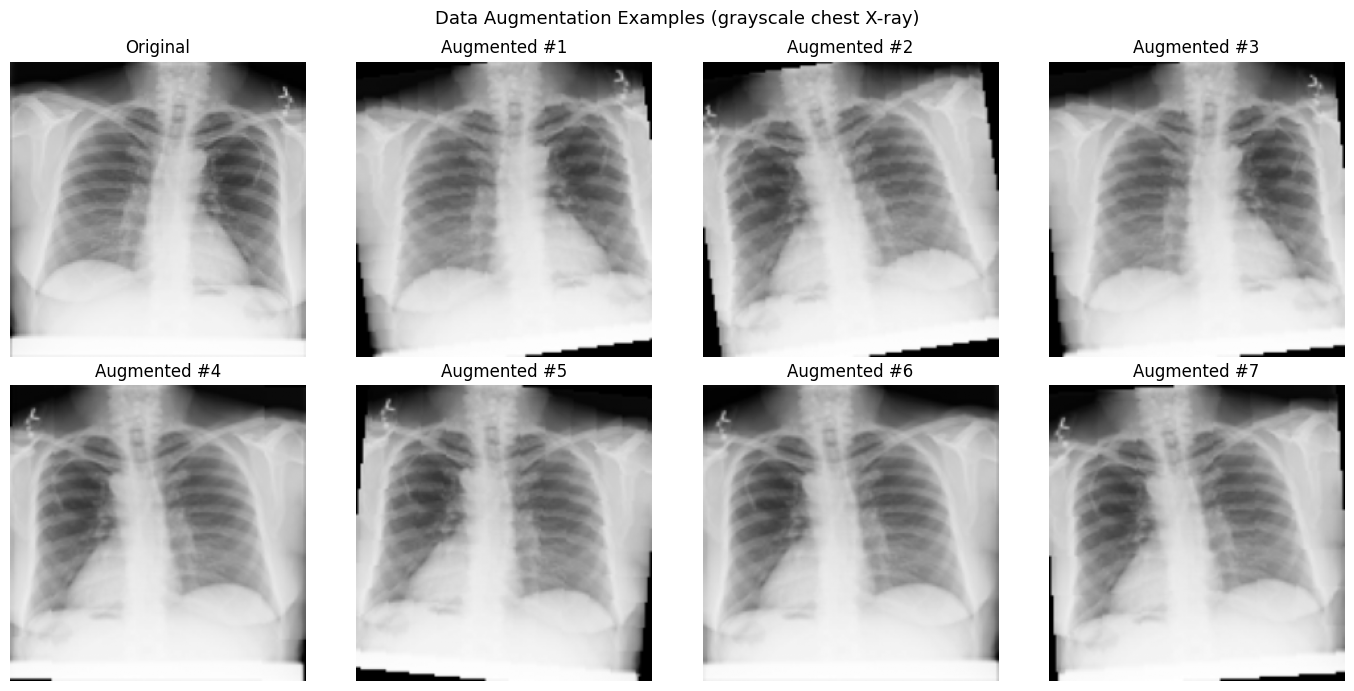

In [7]:
import matplotlib.pyplot as plt

torch.manual_seed(SEED)

# Pick one sample and show it augmented 6 times
sample_idx = 0
original_img = train_dataset.images[sample_idx].convert('L')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(original_img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    aug_img = aug_transform(original_img)
    ax.imshow(aug_img, cmap='gray')
    ax.set_title(f'Augmented #{i+1}')
    ax.axis('off')

fig.suptitle('Data Augmentation Examples (grayscale chest X-ray)', fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'augmentation_examples.png', dpi=150)
plt.show()

## 5. DataLoaders

In [8]:
# Use an attenuated pos_weight = 2 * sqrt(n_neg / n_pos) instead of the full ratio.
# The naive ratio (~189) tends to over-correct on highly imbalanced sets,
# pushing the model to predict pneumonia for almost everything.
train_labels = train_dataset.labels[:, 1]  # index 1 = pneumonia
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
prop_pos_weight = n_pos / (n_pos+n_neg)
print(f"Proportion of positive samples: {prop_pos_weight*100:.4f}%")

# to balance to X% positive cases and (1-X)% negative cases
x_desired = 0.1  # desired proportion of positive cases
pos_weight = (x_desired * (n_neg / n_pos)) / 0.5
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)
# pos_weight = torch.tensor(2 * np.sqrt(n_neg / n_pos), dtype=torch.float32).to(DEVICE)

print(f"Train — Healthy: {int(n_neg)} | Pneumonia: {int(n_pos)}")
print(f"Raw ratio: {n_neg/n_pos:.2f}")
print(f"Attenuated pos_weight: {pos_weight.item():.2f}")

Proportion of positive samples: 0.5274%
Train — Healthy: 42436 | Pneumonia: 225
Raw ratio: 188.60
Attenuated pos_weight: 37.72


In [9]:
train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 6. Model, Loss, Optimizer

In [10]:
torch.manual_seed(SEED)

model     = SimpleCNN(dropout_rate=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
     

## 7. Training Loop

In [11]:
best_val_auc, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    device=DEVICE,
)

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 01/100 | elapsed_time=1839.75s| train_loss=0.5458 | train_auc=0.5593 | val_loss=0.7457 | val_auc=0.5481 ← best 
Epoch 02/100 | elapsed_time=2050.86s| train_loss=0.5386 | train_auc=0.5786 | val_loss=0.6497 | val_auc=0.5727 ← best 
Epoch 03/100 | elapsed_time=2055.83s| train_loss=0.5409 | train_auc=0.5770 | val_loss=0.7100 | val_auc=0.5925 ← best 
Epoch 04/100 | elapsed_time=2054.70s| train_loss=0.5449 | train_auc=0.5713 | val_loss=0.6813 | val_auc=0.5807 
Epoch 05/100 | elapsed_time=2054.27s| train_loss=0.5352 | train_auc=0.5936 | val_loss=0.7071 | val_auc=0.5746 
Epoch 06/100 | elapsed_time=2056.59s| train_loss=0.5396 | train_auc=0.5716 | val_loss=0.6706 | val_auc=0.5865 
Epoch 07/100 | elapsed_time=2052.14s| train_loss=0.5344 | train_auc=0.5880 | val_loss=0.6614 | val_auc=0.5907 
Epoch 08/100 | elapsed_time=2063.04s| train_loss=0.5177 | train_auc=0.6409 | val_loss=0.7234 | val_auc=0.5933 ← best 
Epoch 09/100 | elapsed_time=2050.06s| train_loss=0.5247 | train_auc=0.6258 | val_los

## 8. Training Curves

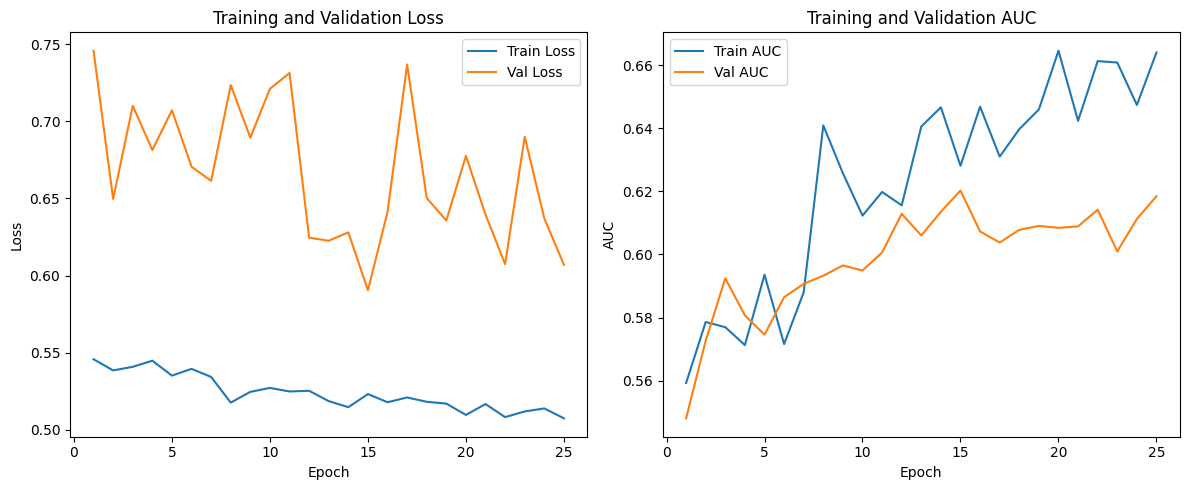

<Figure size 640x480 with 0 Axes>

In [12]:
training_curves(history, results_path=RESULTS_DIR / "training_curves.png")

## 9. Evaluation on Test Set

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

criterion = criterion.to(DEVICE)
_, test_y, test_scores = run_epoch(test_loader, model.to(DEVICE), criterion, device=DEVICE)
_, val_y, val_sc = run_epoch(val_loader, model.to(DEVICE), criterion, device=DEVICE)

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_threshold = thresholds[np.argmax(tpr - fpr)]

print("=== Test Set Metrics ===")
print_metrics(test_y, test_scores, threshold=best_threshold)

=== Test Set Metrics ===
Accuracy : 0.4255
AUC-ROC  : 0.5790
Confusion matrix (threshold=0.09964095801115036):
  TN=3808  FP=5170
  FN=13  TP=30


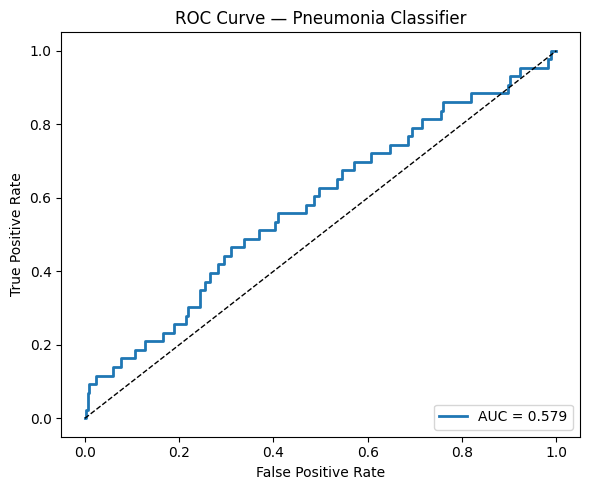

In [14]:
fig = plot_roc_curve(test_y, test_scores, save_path=RESULTS_DIR / "roc_curve_augmented.png")
plt.show()

## 10. Save Results

In [15]:
def ns_to_dict(ns):
    """Convert SimpleNamespace (or None) to plain dict for JSON."""
    return vars(ns) if ns is not None else None

In [16]:
ns_to_dict(cfg.data.augmentations)

{'random_rotation_degrees': 10,
 'horizontal_flip_p': 0.5,
 'random_resized_crop_scale': [0.95, 1.0]}

In [17]:
from metrics import compute_accuracy, compute_roc_auc

save_results(
    model = cfg.model.name,
    img_size = list(IMG_SIZE),
    epochs = NUM_EPOCHS,
    batch_size = BATCH_SIZE,
    lr = LR,
    dropout = DROPOUT,
    seed = SEED,
    pos_weight = pos_weight,
    augmentation = ns_to_dict(cfg.data.augmentations),
    best_val_auc = best_val_auc,
    test_accuracy = compute_accuracy(test_y, test_scores, threshold=best_threshold),
    test_auc_roc =  compute_roc_auc(test_y, test_scores),
    history = history,
    results_path = RESULTS_DIR / f"{cfg.model.name}_results.json"
)

Results saved to C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\augmented_cnn_20260615-001836\SimpleCNN_augmented_results.json
{
  "model": "SimpleCNN_augmented",
  "img_size": [
    224,
    224
  ],
  "epochs": 100,
  "batch_size": 64,
  "lr": 0.0003,
  "dropout": 0.3,
  "seed": 42,
  "pos_weight": 37.7209,
  "augmentation": {
    "random_rotation_degrees": 10,
    "horizontal_flip_p": 0.5,
    "random_resized_crop_scale": [
      0.95,
      1.0
    ]
  },
  "best_val_auc": 0.6203,
  "test_accuracy": 0.4255,
  "test_auc_roc": 0.579
}
